## Project: Manchu-English Translation, Attempt 1 sequence-to-sequence with Attention

In [2]:
!pip install sacrebleu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 5.2 MB/s eta 0:00:00


In [3]:
BASE_DIR = '/content/drive/MyDrive/2025nn'

## Attempt 1: sequence-to-sequence + Additive attention

In [4]:
# 🍒
import os
import random
import math
import matplotlib.pyplot as plt

import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sacrebleu import corpus_bleu

In [6]:
SEED = 6600
random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

fpath = "/content/drive/MyDrive/2025nn/parallel.csv"
val_fpath = "/content/drive/MyDrive/2025nn/cathay-validation.csv"
src_col = "manchu"
tgt_col = "english"

output_fpath = "./runs/attempt1"
os.makedirs(output_fpath, exist_ok=True)

MAX_SRC_LEN = 50
MAX_TGT_LEN = 50
BATCH_SIZE = 16
EPOCHS = 20
LR = 1e-3
EMB_SIZE = 256
HIDDEN_SIZE = 512
DROPOUT = 0.2

# prepare for later maually introduce special tokens
PAD_IDX = 0
BOS_IDX = 1
EOS_IDX = 2

### Data Prep

In [7]:
# load data and apply train, test, validation splits
def load_splits():
    df = pd.read_csv(fpath)
    src_all = tuple(df[src_col].astype(str))
    tgt_all = tuple(df[tgt_col].astype(str))

    train_src, test_src, train_tgt, test_tgt = train_test_split(
        src_all, tgt_all, test_size=0.25, random_state=SEED
    )

    # val_df = pd.read_csv(val_fpath)
    # val_src = tuple(val_df[src_col].astype(str))
    # val_tgt = tuple(val_df[tgt_col].astype(str))
    val_src, test_src, val_tgt, test_tgt = train_test_split(
        test_src, test_tgt, test_size=0.5, random_state=SEED
    )

    return train_src, train_tgt, val_src, val_tgt, test_src, test_tgt

#### Build a word-level Vocab for token-index mappings

In [1]:
class Vocab:
    def __init__(self):
        self.word2index = {"<pad>": 0, "<bos>": 1, "<eos>": 2, "<unk>": 3}
        self.index2word = {i: s for s, i in self.word2index.items()}

    def build(self, texts):
        for sent in texts:
            for tok in sent.split():
                if tok not in self.word2index:
                    idx = len(self.word2index)
                    self.word2index[tok] = idx
                    self.index2word[idx] = tok

    def encode(self, sent, max_len):
        ids = [self.word2index.get(t, self.word2index["<unk>"]) for t in sent.split()]
        ids = ids[: max_len - 2]
        return [BOS_IDX] + ids + [EOS_IDX]

    def decode(self, ids):
        toks = []
        for i in ids:
            if i == EOS_IDX:
                break
            if i not in (PAD_IDX, BOS_IDX):
                toks.append(self.index2word.get(i, "<unk>"))
        return " ".join(toks)

#### Prepare source and target tensor pairs, padding and batching

In [11]:
# dataset class
class PairDataset(Dataset):
    def __init__(self, src, tgt, src_vocab, tgt_vocab):
        self.src = src
        self.tgt = tgt
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.src_vocab.encode(self.src[idx], MAX_SRC_LEN)),
            torch.tensor(self.tgt_vocab.encode(self.tgt[idx], MAX_TGT_LEN)),
        )

# custom collate function
def collate_fn(batch):
    src, tgt = zip(*batch)
    src = nn.utils.rnn.pad_sequence(src, batch_first=True, padding_value=PAD_IDX)
    tgt = nn.utils.rnn.pad_sequence(tgt, batch_first=True, padding_value=PAD_IDX)
    return src, tgt

## Define the Model

- reference: https://docs.pytorch.org/tutorials/intermediate/seq2seq_translation_tutorial.html

In [20]:
# encoder: embedding >> one GRU layer
class Encoder(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, EMB_SIZE, padding_idx=PAD_IDX)
        self.gru = nn.GRU(EMB_SIZE, HIDDEN_SIZE, batch_first=True)

    def forward(self, x):
        emb = self.emb(x)
        outputs, hidden = self.gru(emb)
        return outputs, hidden

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size)
        self.Ua = nn.Linear(hidden_size, hidden_size)
        self.Va = nn.Linear(hidden_size, 1)

    def forward(self, query, keys):
        scores = self.Va(torch.tanh(self.Wa(query) + self.Ua(keys)))
        scores = scores.squeeze(2).unsqueeze(1)

        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights, keys)

        return context, weights
# class Attention(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.attn = nn.Linear(HIDDEN_SIZE * 2, HIDDEN_SIZE)
#         self.v = nn.Linear(HIDDEN_SIZE, 1, bias=False)

#     def forward(self, hidden, enc_outputs):
#         T = enc_outputs.size(1)
#         hidden = hidden.unsqueeze(1).repeat(1, T, 1)
#         energy = torch.tanh(self.attn(torch.cat([hidden, enc_outputs], dim=2)))
#         return F.softmax(self.v(energy).squeeze(2), dim=1)

class Decoder(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, EMB_SIZE, padding_idx=PAD_IDX)
        self.gru = nn.GRU(EMB_SIZE + HIDDEN_SIZE, HIDDEN_SIZE, batch_first=True)
        self.fc = nn.Linear(HIDDEN_SIZE, vocab_size)
        self.attn = BahdanauAttention(HIDDEN_SIZE)

    # def forward(self, x, hidden, enc_outputs):
    #     emb = self.emb(x).unsqueeze(1)
    #     attn_w = self.attn(hidden[-1], enc_outputs).unsqueeze(1)
    #     context = torch.bmm(attn_w, enc_outputs)
    #     gru_in = torch.cat([emb, context], dim=2)
    #     out, hidden = self.gru(gru_in, hidden)
    #     logits = self.fc(out.squeeze(1))
    #     return logits, hidden
    def forward(self, x, hidden, enc_outputs):
        emb = self.emb(x).unsqueeze(1)        # (B, 1, EMB)

        query = hidden[-1].unsqueeze(1)       # (B, 1, H)
        context, attn_w = self.attn(query, enc_outputs)

        gru_in = torch.cat([emb, context], dim=2)
        out, hidden = self.gru(gru_in, hidden)

        logits = self.fc(out.squeeze(1))
        return logits, hidden


class Seq2Seq(nn.Module):
    def __init__(self, enc, dec):
        super().__init__()
        self.enc = enc
        self.dec = dec

    def forward(self, src, tgt):
        enc_outs, hidden = self.enc(src)
        logits = []
        for t in range(tgt.size(1) - 1):
            out, hidden = self.dec(tgt[:, t], hidden, enc_outs)
            logits.append(out)
        return torch.stack(logits, dim=1)


## Training

In [23]:
# cross entropy loss for machine translation
loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_IDX) # padding mask

def train_epoch(model, loader, opt):
    model.train()
    total = 0.0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        logits = model(src, tgt)
        loss = loss_fn(
            logits.reshape(-1, logits.size(-1)),   # batch * len, num of classes
            tgt[:, 1:].reshape(-1)
        )
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        total += loss.item()
    return total / len(loader)

#### validation and evaluation helpers

In [21]:
@torch.no_grad()
def eval_loss(model, loader):
    model.eval()
    total = 0.0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        logits = model(src, tgt)
        loss = loss_fn(logits.reshape(-1, logits.size(-1)), tgt[:, 1:].reshape(-1))
        total += loss.item()
    return total / len(loader)


@torch.no_grad()
def translate(model, src_sent, src_vocab, tgt_vocab):
    model.eval()
    src = torch.tensor([src_vocab.encode(src_sent, MAX_SRC_LEN)], device=device)
    enc_outs, hidden = model.enc(src)

    out_ids = [BOS_IDX]
    for _ in range(MAX_TGT_LEN):
        x = torch.tensor([out_ids[-1]], device=device)
        logits, hidden = model.dec(x, hidden, enc_outs)
        nxt = logits.argmax(-1).item()
        if nxt == EOS_IDX:
            break
        out_ids.append(nxt)

    return tgt_vocab.decode(out_ids)


def compute_bleu(preds, refs):
    return corpus_bleu(preds, [refs]).score


def pretty_samples(src, ref, hyp, k=8):
    out = []
    for i in range(min(k, len(src))):
        out.append(
            f"SRC: {src[i]}\n"
            f"REF: {ref[i]}\n"
            f"GEN: {hyp[i]}\n"
            + "-" * 60
        )
    return "\n".join(out)

## Attempt 1.6: Best

Epoch 01 | Train 5.679 | Val 5.428 | BLEU 0.60 ✓loss ✓bleu
Epoch 02 | Train 4.836 | Val 5.389 | BLEU 0.41 ✓loss
Epoch 03 | Train 4.189 | Val 5.403 | BLEU 0.38
Epoch 04 | Train 3.552 | Val 5.349 | BLEU 0.88 ✓loss ✓bleu
Epoch 05 | Train 2.925 | Val 5.449 | BLEU 0.89 ✓bleu
Epoch 06 | Train 2.205 | Val 5.586 | BLEU 0.71
Epoch 07 | Train 1.772 | Val 5.612 | BLEU 0.66
Epoch 08 | Train 1.257 | Val 5.735 | BLEU 1.18 ✓bleu
Epoch 09 | Train 0.844 | Val 5.731 | BLEU 0.85
Epoch 10 | Train 0.525 | Val 5.855 | BLEU 0.40
Epoch 11 | Train 0.335 | Val 6.003 | BLEU 0.69
Epoch 12 | Train 0.208 | Val 6.169 | BLEU 0.39
Epoch 13 | Train 0.138 | Val 6.172 | BLEU 0.62
Epoch 14 | Train 0.090 | Val 6.270 | BLEU 0.38
Epoch 15 | Train 0.064 | Val 6.291 | BLEU 0.35
Epoch 16 | Train 0.052 | Val 6.402 | BLEU 0.37
Epoch 17 | Train 0.044 | Val 6.416 | BLEU 0.38
Epoch 18 | Train 0.042 | Val 6.500 | BLEU 0.38
Epoch 19 | Train 0.042 | Val 6.595 | BLEU 0.38
Epoch 20 | Train 0.035 | Val 6.555 | BLEU 0.37


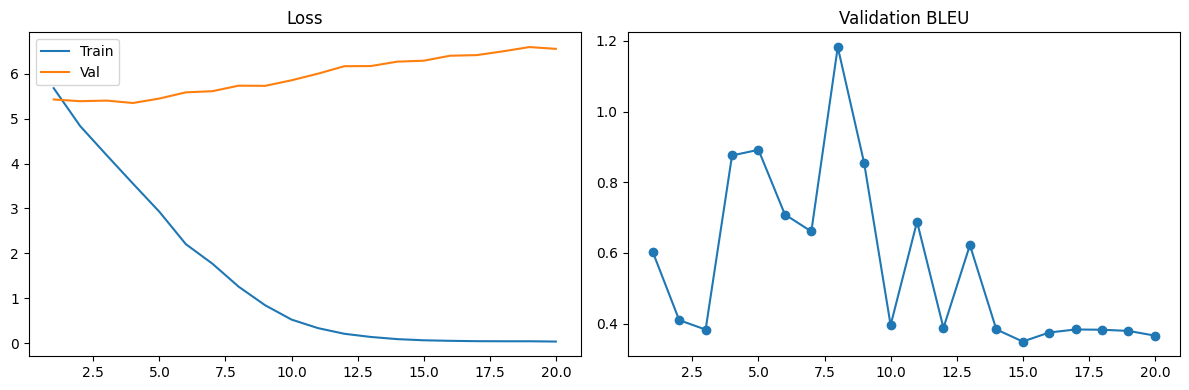


=== TEST (best_val_loss) ===
BLEU: 0.7163504185598015
SRC: manggai amba tacin i bithe dabala
REF: it is the great learning
GEN: i have been
------------------------------------------------------------
SRC: bi umai seme gisurehekv
REF: i was not saying anything
GEN: i have been to go
------------------------------------------------------------
SRC: doron be waliyabuci ja baita
REF: the loss of a seal is an ordinary occurrence after all
GEN: i have been to tell me
------------------------------------------------------------
SRC: xi halai nun simbe aliyame tehebi
REF: cousin shih is waiting for you
GEN: i have been to see
------------------------------------------------------------
SRC: jiduji loo tai tai fulu kai
REF: your venerable ladyship
GEN: i have been to tell me
------------------------------------------------------------
SRC: yafan i dergi amargi hoxoi bade
REF: supply of pine and cedar trees in the northeast corner of the park
GEN: i have been to see
---------------------------

In [ ]:
def main():
    train_src, train_tgt, val_src, val_tgt, test_src, test_tgt = load_splits()

    src_vocab = Vocab()
    tgt_vocab = Vocab()
    src_vocab.build(train_src)
    tgt_vocab.build(train_tgt)

    train_loader = DataLoader(
        PairDataset(train_src, train_tgt, src_vocab, tgt_vocab),
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=collate_fn,
    )
    val_loader = DataLoader(
        PairDataset(val_src, val_tgt, src_vocab, tgt_vocab),
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_fn,
    )

    model = Seq2Seq(
        Encoder(len(src_vocab.word2index)),
        Decoder(len(tgt_vocab.word2index)),
    ).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=LR)

    history = []
    best_loss = float("inf")
    best_bleu = -1.0

    for epoch in range(1, EPOCHS + 1):
        tr = train_epoch(model, train_loader, opt)
        vl = eval_loss(model, val_loader)
        preds = [translate(model, s, src_vocab, tgt_vocab) for s in val_src]
        vb = compute_bleu(preds, list(val_tgt))

        history.append(dict(epoch=epoch, train_loss=tr, val_loss=vl, val_bleu=vb))

        if vl <= best_loss:
            best_loss = vl
            torch.save(model.state_dict(), f"{output_fpath}/best_val_loss.pt")

        if vb >= best_bleu:
            best_bleu = vb
            torch.save(model.state_dict(), f"{output_fpath}/best_val_bleu.pt")

        if epoch == 15:
            torch.save(model.state_dict(), f"{output_fpath}/a15-fitter.pt")

        print(
            f"Epoch {epoch:02d} | Train {tr:.3f} | Val {vl:.3f} | BLEU {vb:.2f}"
            f"{' ✓loss' if vl <= best_loss else ''}{' ✓bleu' if vb >= best_bleu else ''}"
        )


    # ---- PLOTS ----
    epochs = [h["epoch"] for h in history]
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, [h["train_loss"] for h in history], label="Train")
    plt.plot(epochs, [h["val_loss"] for h in history], label="Val")
    plt.legend(); plt.title("Loss")

    plt.subplot(1,2,2)
    plt.plot(epochs, [h["val_bleu"] for h in history], marker="o")
    plt.title("Validation BLEU")
    plt.tight_layout()
    plt.savefig(f"{output_fpath}/curves.png")
    plt.show()

    # ---- TEST (both checkpoints) ----
    for tag in ["best_val_loss", "best_val_bleu", 'a15-fitter']:
        print(f"\n=== TEST ({tag}) ===")
        model.load_state_dict(torch.load(f"{output_fpath}/{tag}.pt"))
        preds = [translate(model, s, src_vocab, tgt_vocab) for s in test_src]
        print("BLEU:", compute_bleu(preds, list(test_tgt)))
        print(pretty_samples(test_src, test_tgt, preds))


if __name__ == "__main__":
    main()
